[2026-08-03 16:14:29] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-03 16:14:29] [info     ] AI 特征构建开始                      end='2023-12-31 23:59:59' need_label=True start='2019-01-01 00:00:00'
[2026-08-03 16:18:52] [info     ] AI 特征构建完成                      elapsed=262.19 features=35 rows=1214000
[2026-08-03 16:18:52] [info     ] HistGradientBoosting 开始训练      features=35 samples=600000
[2026-08-03 16:19:04] [info     ] HistGradientBoosting 训练完成      elapsed=11.27
[2026-08-03 16:19:04] [info     ] AI 特征构建开始                      end='2024-12-31 23:59:59' need_label=False start='2024-01-01 00:00:00'
[2026-08-03 16:20:14] [info     ] AI 特征构建完成                      elapsed=70.73 features=35 rows=242000
[2026-08-03 16:20:16] [info     ] AI 因子构建完成                      missing_rate=0.0 rows=242000
[2026-08-03 16:20:16] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-03 16:20:17] [warning  ] bigalpha_eval._latest version='v4' (use ._latest fo

时段,IC
2024-01-15~2024-02-08,0.0053
2024-09-24~2024-10-08,0.0096

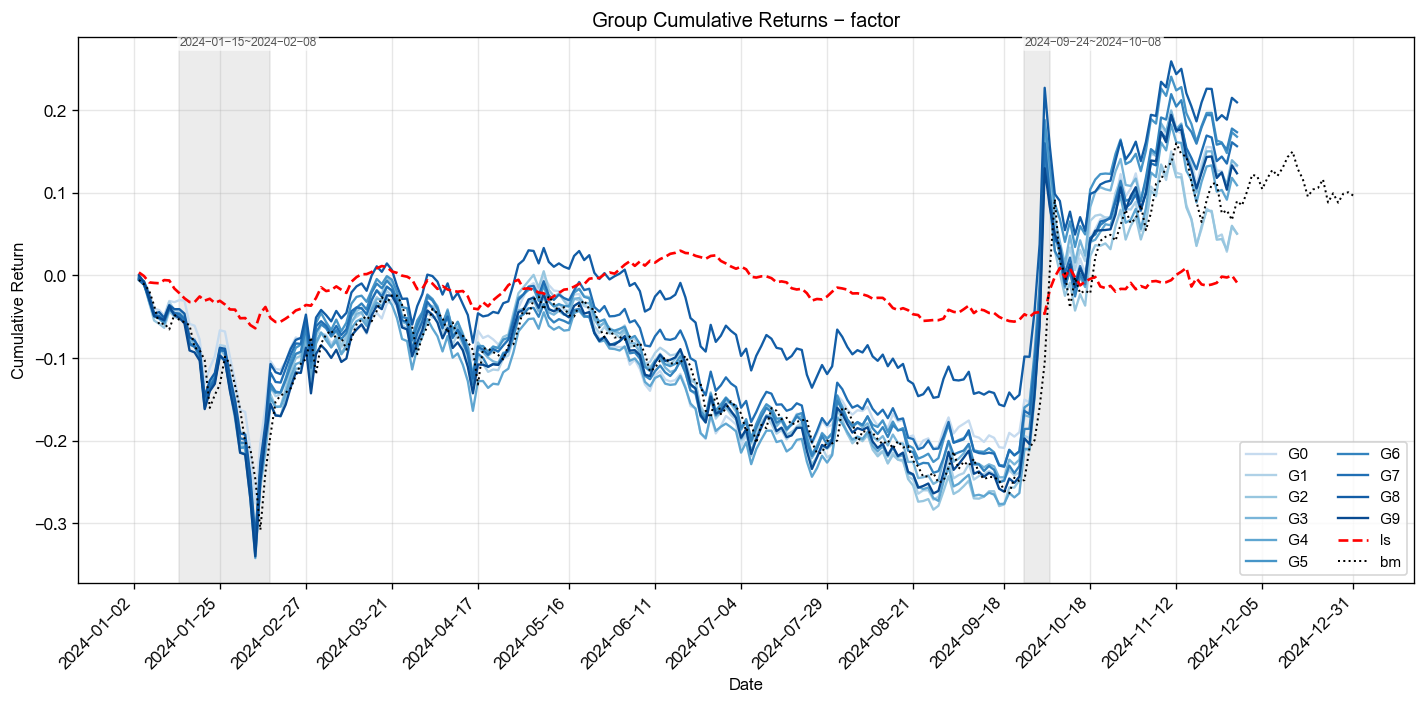
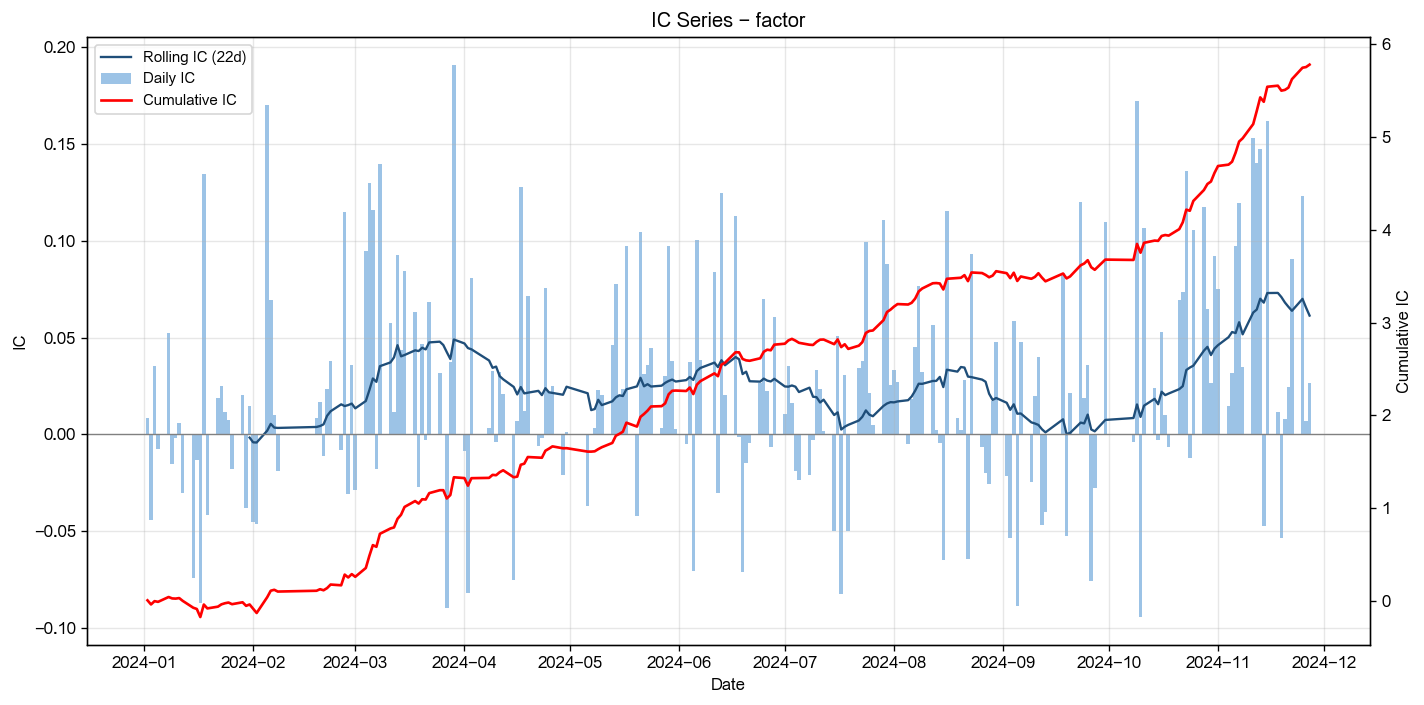
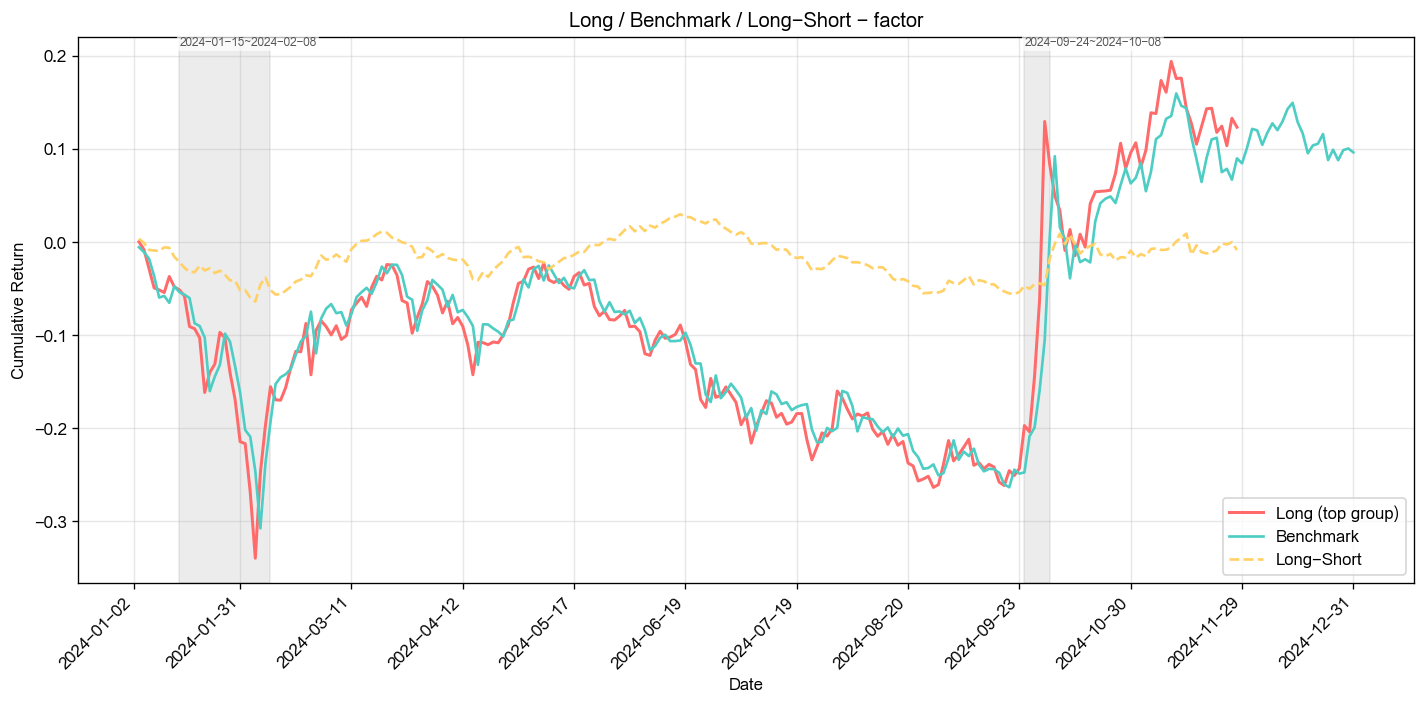
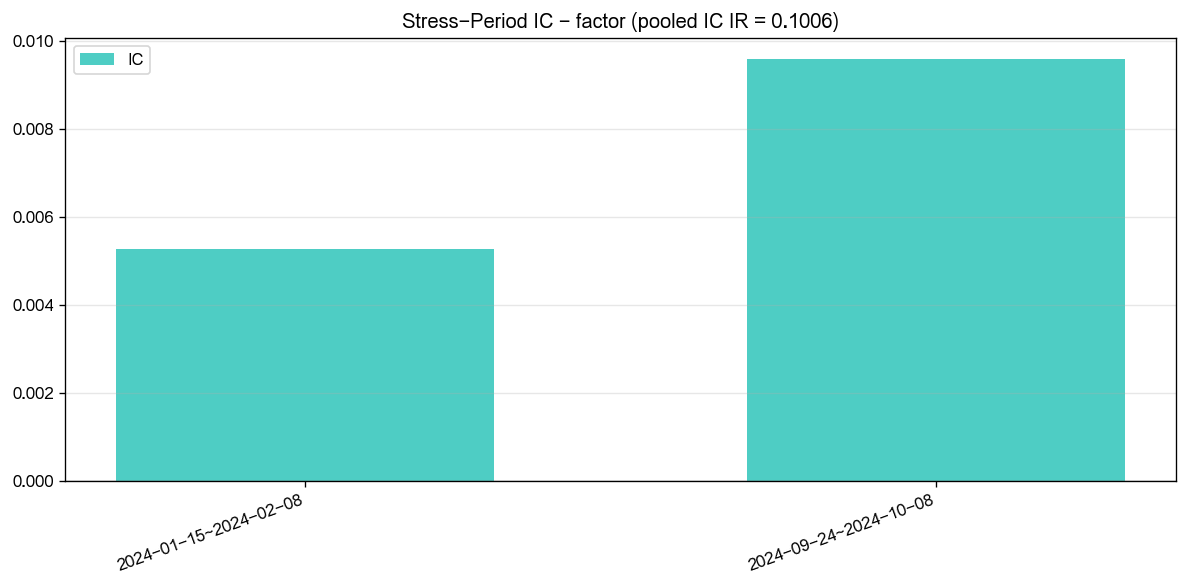
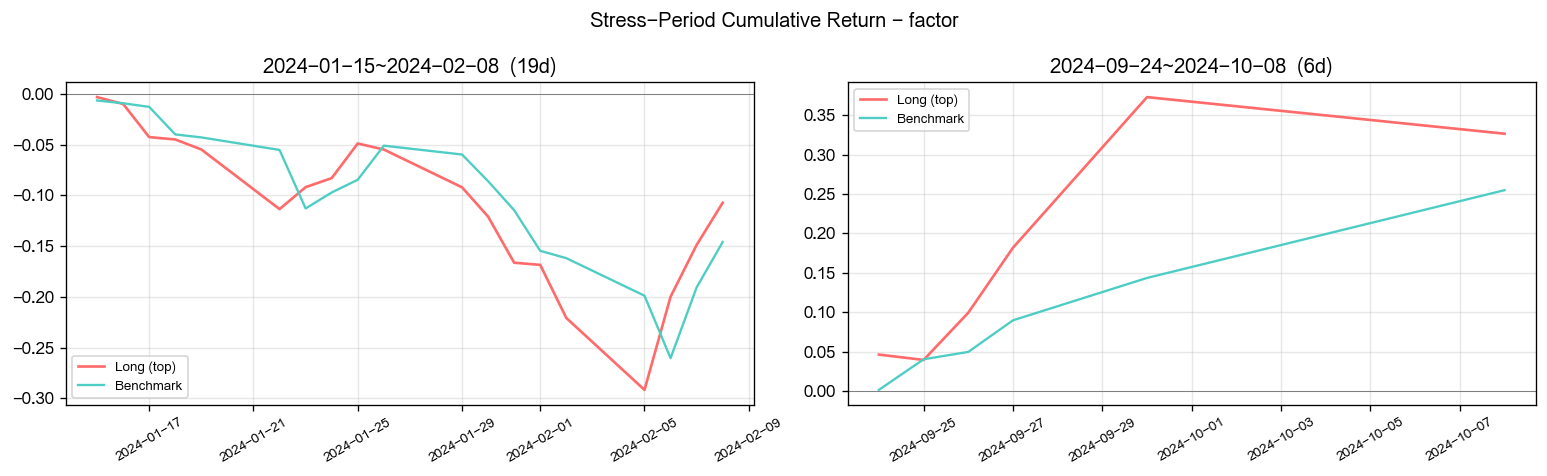

[2026-08-03 16:22:07] [info     ] ========== 因子池回归 ==========
[2026-08-03 16:22:07] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-03 16:22:08] [info     ] 获取收益率数据, 耗时: 1.0743 秒
[2026-08-03 16:22:10] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.846 秒
[2026-08-03 16:22:10] [info     ] 统计 回归结果, 耗时: 0.0127 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,2.0439,0.0444,0.0217,1.0000
2,amount,1.7045,0.0182,0.0107,0.9000
3,netflow_amount_main,1.5126,0.0254,0.0168,1.0000
4,gross_profit_rate_ttm,1.4985,0.0069,0.0046,1.0000
5,pb,1.4680,0.0100,0.0068,0.9000
6,net_profit_rate_ttm,1.4664,0.0040,0.0027,0.8000
7,bias_20,1.4338,0.0292,0.0204,0.9000
8,cci_14,1.3964,0.0340,0.0243,1.0000
9,netflow_amount_rate_main,1.3849,0.0093,0.0067,1.0000
10,macd_hist_12_26_9,1.3097,0.0064,0.0049,1.0000

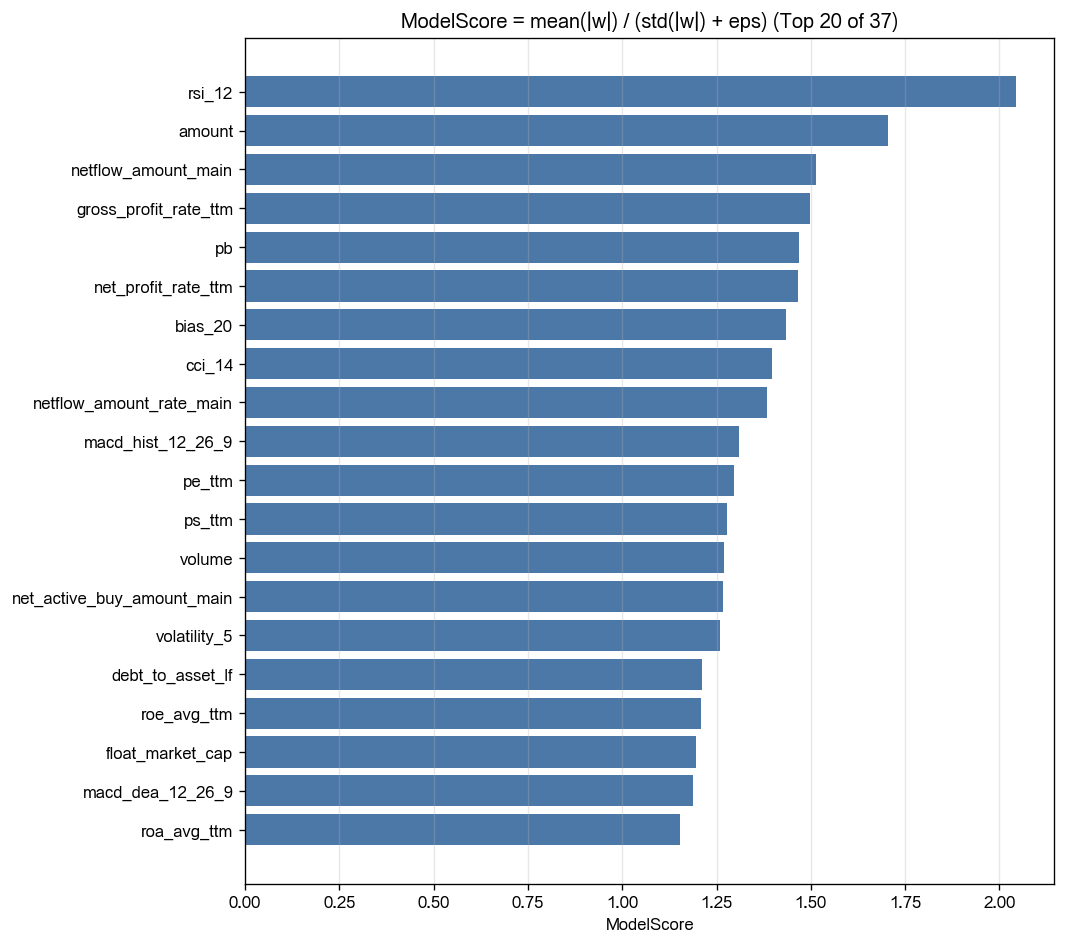
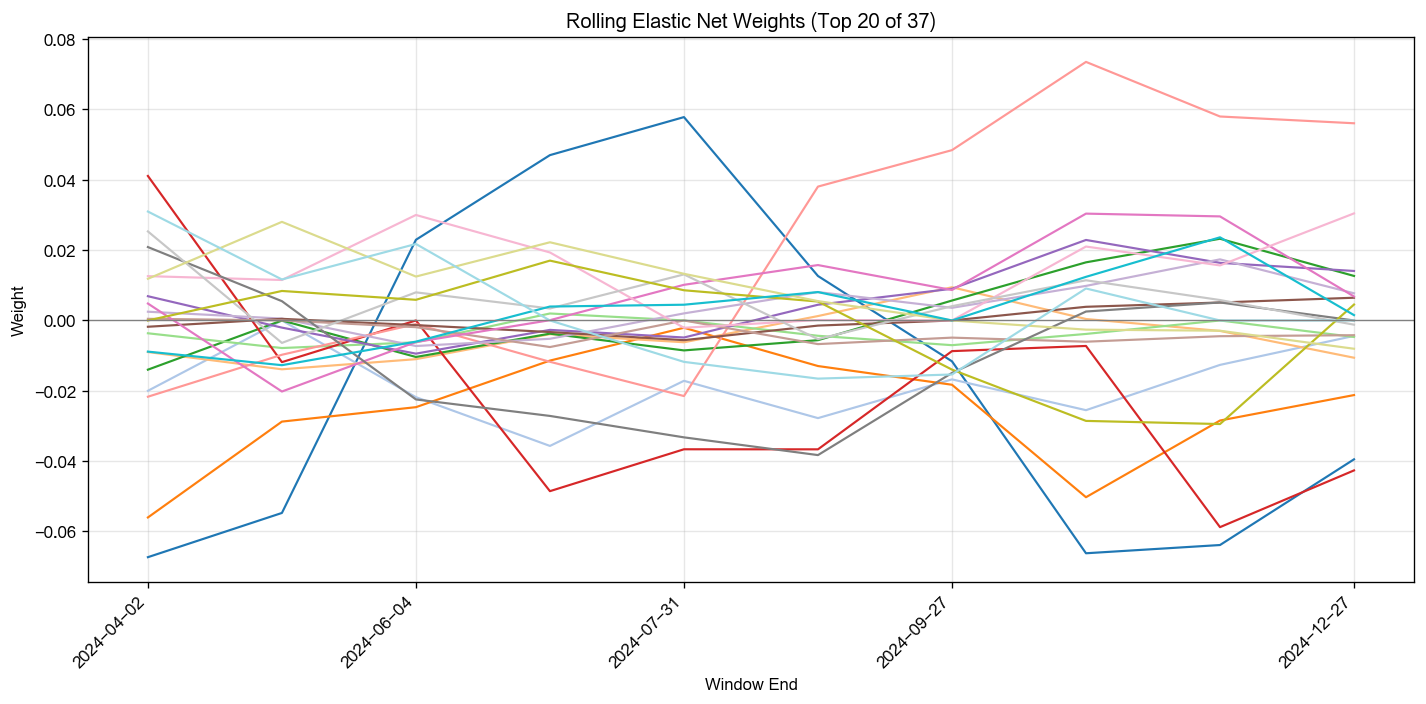
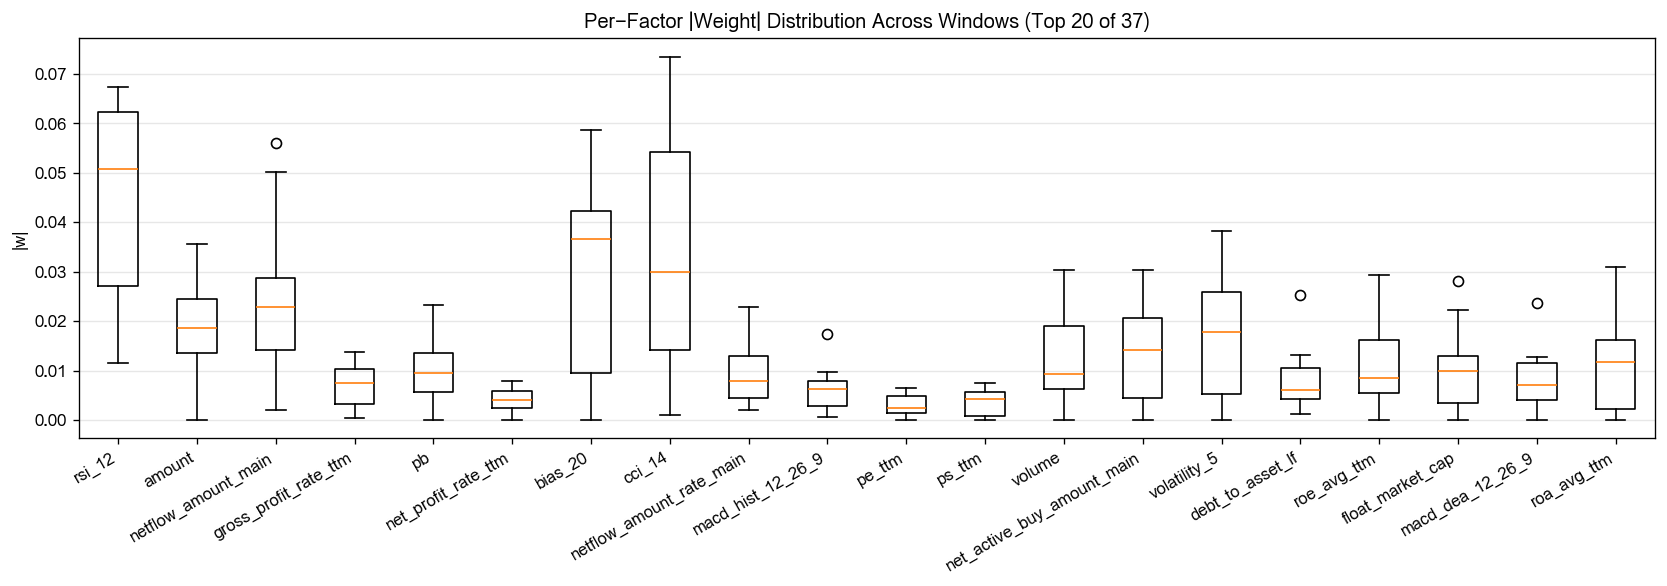
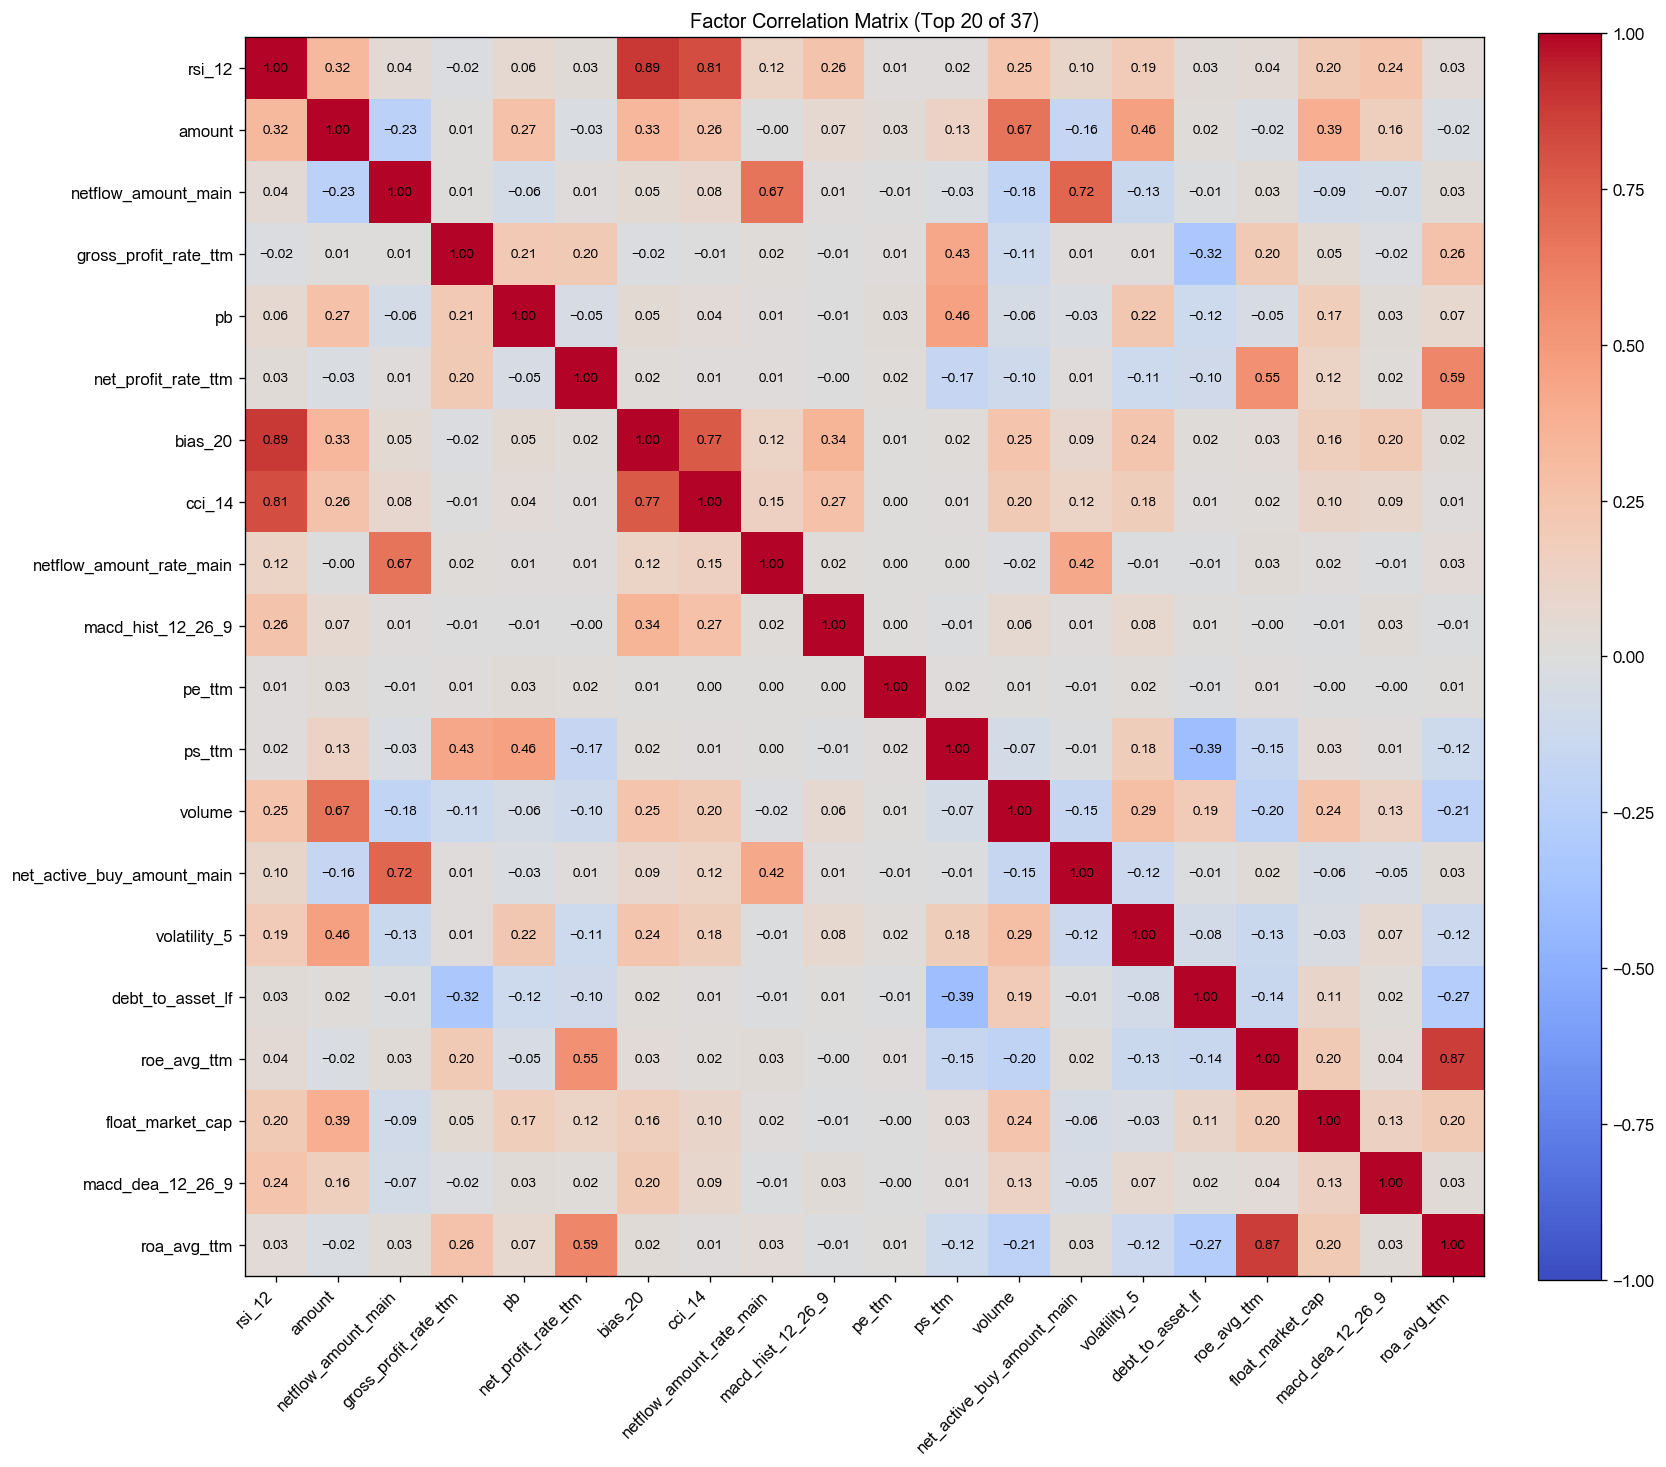

[2026-08-03 16:22:12] [warning  ] 返回的Outputs实例(size=33653502) 大于 64K, 将不会被缓存
[2026-08-03 16:22:12] [info     ] bigalpha_eval.v4 运行完成 [112.260s].


In [1]:
def main(datasources, start_date, end_date):
    """
    AI 因子：微观结构 × 财务质量非线性交互（HistGradientBoosting）。

    AI 技术应用关键环节：
    1. 自动化特征工程：从 1 分钟五档盘口聚合订单簿不平衡、价差、
    深浅档分歧和成交活跃度，再构造时序稳定性与冲击特征；
    2. PIT 财务特征：以公告日为生效日，构造现金利润质量、研发强度、
    营运资本压力等传统基础因子库较少覆盖的质量特征；
    3. 非线性模型：使用直方图梯度提升树自动学习微观结构与财务质量
    之间的阈值效应及交互关系；
    4. 样本外约束：训练区间固定为公开历史数据，平台传入区间只预测，
    且标签为下一交易日横截面收益排名，避免测试集训练和市场方向泄漏。

    评测时平台只替换 datasources / start_date / end_date 三个入参。

    返回：
        pd.DataFrame，严格且仅包含 ['date', 'instrument', 'factor'] 三列。
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import structlog
    from sklearn.ensemble import HistGradientBoostingRegressor

    logger = structlog.get_logger()

    # 公开训练数据允许使用 2019-2024。取最近三年兼顾多市场环境、
    # 制度时效性和 3 小时运行限制；绝不使用平台注入的测试区间训练。
    TRAIN_START = '2019-01-01 00:00:00'
    TRAIN_END = '2023-12-31 23:59:59'
    TRAIN_BAR_TABLE = 'bigalpha_2026_stock_bar1m'
    TRAIN_FINANCIAL_TABLE = 'bigalpha_2026_financial'
    MAX_TRAIN_SAMPLES = 600_000
    EPS = 1e-12

    price_feature_cols = [
        'ret_1d',
        'ret_5d',
        'ret_20d',
        'ret_60d',
        'gap',
        'intraday_ret',
        'range_pct',
        'close_location',
        'intraday_dispersion',
        'volatility_20',
        'price_efficiency_20',
        'volume_shock_20',
        'amount_shock_20',
        'trade_size_shock_20',
        'spread_mean',
        'spread_volatility',
        'spread_shock_20',
        'book_imbalance_mean',
        'book_imbalance_volatility',
        'book_imbalance_close',
        'imbalance_shift',
        'imbalance_persistence_5',
        'depth_divergence_mean',
        'depth_divergence_close',
        'depth_persistence_5',
        'quote_coverage',
    ]
    financial_feature_cols = [
        'cash_profit_quality',
        'gross_margin',
        'rd_intensity',
        'working_capital_pressure',
        'asset_turnover',
        'net_margin',
    ]
    interaction_feature_cols = [
        'spread_imbalance_interaction',
        'reversal_pressure_interaction',
        'quality_liquidity_interaction',
    ]
    feature_cols = (
        price_feature_cols
        + financial_feature_cols
        + interaction_feature_cols
    )

    raw_daily_cols = [
        'open',
        'pre_close',
        'high',
        'low',
        'close',
        'adjusted_close',
        'volume',
        'amount',
        'deal_number',
        'avg_close',
        'std_close',
        'valid_minutes',
        'quote_minutes',
        'spread_mean',
        'spread_std',
        'book_imbalance_mean_raw',
        'book_imbalance_std_raw',
        'book_imbalance_close_raw',
        'depth_divergence_mean_raw',
        'depth_divergence_close_raw',
        'avg_trade_amount',
    ]

    def load_stock_pool(sd, ed):
        pool = dai.query(
            "SELECT date, instrument FROM bigalpha_2026_instruments",
            filters={'date': [sd, ed]},
        ).df()
        pool['date'] = pd.to_datetime(pool['date']).dt.normalize()
        pool = (
            pool[['date', 'instrument']]
            .dropna(subset=['date', 'instrument'])
            .drop_duplicates()
        )
        pool['instrument'] = pool['instrument'].astype(str)
        return pool

    def query_daily_market(bar1m_table, sd, ed):
        """分钟数据在 SQL 端聚合为日频，避免把海量分钟记录拉入 pandas。"""
        sd_day = pd.Timestamp(sd).normalize()
        query_start = (
            sd_day - pd.Timedelta(days=120)
        ).strftime('%Y-%m-%d %H:%M:%S')

        sql = f"""
        WITH cte_raw AS (
            SELECT
                date,
                date_trunc('day', date)::DATE AS trading_day,
                instrument,
                CAST(open AS DOUBLE) AS open_price,
                CAST(pre_close AS DOUBLE) AS pre_close_price,
                CAST(high AS DOUBLE) AS high_price,
                CAST(low AS DOUBLE) AS low_price,
                CAST(close AS DOUBLE) AS close_price,
                CASE
                    WHEN adjust_factor IS NOT NULL AND adjust_factor > 0
                    THEN CAST(close AS DOUBLE) * CAST(adjust_factor AS DOUBLE)
                    ELSE CAST(close AS DOUBLE)
                END AS adjusted_close_price,
                CAST(volume AS DOUBLE) AS minute_volume,
                CAST(amount AS DOUBLE) AS minute_amount,
                CAST(deal_number AS DOUBLE) AS minute_deal_number,
                CAST(ask_price1 AS DOUBLE) AS ask_price1_d,
                CAST(bid_price1 AS DOUBLE) AS bid_price1_d,
                CAST(bid_volume1 AS DOUBLE) + CAST(bid_volume2 AS DOUBLE)
                + CAST(bid_volume3 AS DOUBLE) + CAST(bid_volume4 AS DOUBLE)
                + CAST(bid_volume5 AS DOUBLE) AS bid_depth5,
                CAST(ask_volume1 AS DOUBLE) + CAST(ask_volume2 AS DOUBLE)
                + CAST(ask_volume3 AS DOUBLE) + CAST(ask_volume4 AS DOUBLE)
                + CAST(ask_volume5 AS DOUBLE) AS ask_depth5,
                CAST(bid_volume1 AS DOUBLE) AS bid_depth1,
                CAST(ask_volume1 AS DOUBLE) AS ask_depth1,
                CAST(bid_volume2 AS DOUBLE) + CAST(bid_volume3 AS DOUBLE)
                + CAST(bid_volume4 AS DOUBLE) + CAST(bid_volume5 AS DOUBLE)
                AS bid_depth_deep,
                CAST(ask_volume2 AS DOUBLE) + CAST(ask_volume3 AS DOUBLE)
                + CAST(ask_volume4 AS DOUBLE) + CAST(ask_volume5 AS DOUBLE)
                AS ask_depth_deep
            FROM {bar1m_table}
            WHERE close IS NOT NULL AND close > 0
        ),
        cte_minute_feature AS (
            SELECT
                date,
                trading_day,
                instrument,
                open_price,
                pre_close_price,
                high_price,
                low_price,
                close_price,
                adjusted_close_price,
                minute_volume,
                minute_amount,
                minute_deal_number,
                CASE
                    WHEN ask_price1_d > 0
                    AND bid_price1_d > 0
                    AND ask_price1_d >= bid_price1_d
                    THEN (ask_price1_d - bid_price1_d)
                        / ((ask_price1_d + bid_price1_d) / 2.0)
                    ELSE NULL
                END AS relative_spread,
                CASE
                    WHEN bid_depth5 + ask_depth5 > 0
                    THEN (bid_depth5 - ask_depth5)
                        / (bid_depth5 + ask_depth5)
                    ELSE NULL
                END AS book_imbalance,
                CASE
                    WHEN bid_depth_deep + ask_depth_deep > 0
                    AND bid_depth1 + ask_depth1 > 0
                    THEN (bid_depth_deep - ask_depth_deep)
                        / (bid_depth_deep + ask_depth_deep)
                        - (bid_depth1 - ask_depth1)
                        / (bid_depth1 + ask_depth1)
                    ELSE NULL
                END AS depth_divergence,
                CASE
                    WHEN minute_deal_number > 0 AND minute_amount >= 0
                    THEN minute_amount / minute_deal_number
                    ELSE NULL
                END AS minute_avg_trade_amount
            FROM cte_raw
        )
        SELECT
            trading_day AS date,
            instrument,
            ARG_MIN(open_price, date) AS open,
            ARG_MIN(pre_close_price, date) AS pre_close,
            MAX(high_price) AS high,
            MIN(low_price) AS low,
            ARG_MAX(close_price, date) AS close,
            ARG_MAX(adjusted_close_price, date) AS adjusted_close,
            SUM(minute_volume) AS volume,
            SUM(minute_amount) AS amount,
            SUM(minute_deal_number) AS deal_number,
            AVG(close_price) AS avg_close,
            NANSTD(close_price) AS std_close,
            COUNT(*) AS valid_minutes,
            COUNT(relative_spread) AS quote_minutes,
            AVG(relative_spread) AS spread_mean,
            NANSTD(relative_spread) AS spread_std,
            AVG(book_imbalance) AS book_imbalance_mean_raw,
            NANSTD(book_imbalance) AS book_imbalance_std_raw,
            ARG_MAX(book_imbalance, date) AS book_imbalance_close_raw,
            AVG(depth_divergence) AS depth_divergence_mean_raw,
            ARG_MAX(depth_divergence, date) AS depth_divergence_close_raw,
            AVG(minute_avg_trade_amount) AS avg_trade_amount
        FROM cte_minute_feature
        GROUP BY trading_day, instrument
        """

        daily = dai.query(
            sql,
            filters={'date': [query_start, ed]},
            compression=True,
        ).df()
        if daily.empty:
            return daily

        daily['date'] = pd.to_datetime(daily['date']).dt.normalize()
        daily['instrument'] = daily['instrument'].astype(str)
        for col in raw_daily_cols:
            daily[col] = pd.to_numeric(daily[col], errors='coerce')
        daily[raw_daily_cols] = daily[raw_daily_cols].replace(
            [np.inf, -np.inf], np.nan
        )
        return (
            daily.drop_duplicates(['date', 'instrument'], keep='last')
            .sort_values(['instrument', 'date'])
            .reset_index(drop=True)
        )

    def query_financial_events(financial_table, sd, ed):
        """查询公告事件；TTM 流量与 LF 存量按同一公告日连接。"""
        query_start = (
            pd.Timestamp(sd).normalize() - pd.Timedelta(days=550)
        ).strftime('%Y-%m-%d %H:%M:%S')
        sql = f"""
        WITH cte_ttm AS (
            SELECT
                date,
                instrument,
                CAST(operating_revenue AS DOUBLE) AS operating_revenue_ttm,
                CAST(operating_costs AS DOUBLE) AS operating_costs_ttm,
                CAST(net_profit_to_parent_shareholders AS DOUBLE)
                AS parent_net_profit_ttm,
                CAST(net_cffoa AS DOUBLE) AS operating_cash_flow_ttm,
                CAST(research_and_development_expense AS DOUBLE)
                AS rd_expense_ttm
            FROM {financial_table}
            WHERE category = 'ttm' AND shift = 0
        ),
        cte_lf AS (
            SELECT
                date,
                instrument,
                CAST(total_assets AS DOUBLE) AS total_assets_lf,
                CAST(accounts_receivable AS DOUBLE) AS accounts_receivable_lf,
                CAST(inventories AS DOUBLE) AS inventories_lf
            FROM {financial_table}
            WHERE category = 'lf' AND shift = 0
        )
        SELECT
            date,
            instrument,
            operating_revenue_ttm,
            operating_costs_ttm,
            parent_net_profit_ttm,
            operating_cash_flow_ttm,
            rd_expense_ttm,
            total_assets_lf,
            accounts_receivable_lf,
            inventories_lf
        FROM cte_ttm
        PRUNE JOIN cte_lf USING (date, instrument)
        """
        events = dai.query(
            sql,
            filters={'date': [query_start, ed]},
            compression=True,
        ).df()
        if events.empty:
            return events

        events['date'] = pd.to_datetime(events['date']).dt.normalize()
        events = events.dropna(subset=['date', 'instrument'])
        events['instrument'] = events['instrument'].astype(str)
        value_cols = [
            'operating_revenue_ttm',
            'operating_costs_ttm',
            'parent_net_profit_ttm',
            'operating_cash_flow_ttm',
            'rd_expense_ttm',
            'total_assets_lf',
            'accounts_receivable_lf',
            'inventories_lf',
        ]
        for col in value_cols:
            events[col] = pd.to_numeric(events[col], errors='coerce')
        events[value_cols] = events[value_cols].replace(
            [np.inf, -np.inf], np.nan
        )
        return (
            events.sort_values(['date', 'instrument'])
            .drop_duplicates(['date', 'instrument'], keep='last')
        )

    def add_price_features(daily, need_label):
        """从日频聚合结果自动生成多尺度价格、流动性和盘口特征。"""
        daily = daily.sort_values(['instrument', 'date']).reset_index(drop=True)
        grouped = daily.groupby('instrument', sort=False, observed=True)
        close_group = grouped['adjusted_close']

        daily['ret_1d'] = close_group.pct_change(1, fill_method=None)
        daily['ret_5d'] = close_group.pct_change(5, fill_method=None)
        daily['ret_20d'] = close_group.pct_change(20, fill_method=None)
        daily['ret_60d'] = close_group.pct_change(60, fill_method=None)

        # 新增收益率列后重新建立 GroupBy，避免不同 pandas 版本对旧 GroupBy
        # 对象是否可见新增列的行为差异。
        grouped = daily.groupby('instrument', sort=False, observed=True)
        daily['gap'] = (
            daily['open'] / daily['pre_close'].replace(0, np.nan) - 1.0
        )
        daily['intraday_ret'] = (
            daily['close'] / daily['open'].replace(0, np.nan) - 1.0
        )
        daily['range_pct'] = (
            (daily['high'] - daily['low'])
            / daily['close'].abs().replace(0, np.nan)
        )
        daily['close_location'] = (
            (daily['close'] - daily['low'])
            / (daily['high'] - daily['low']).replace(0, np.nan)
        ).clip(0.0, 1.0)
        daily['intraday_dispersion'] = (
            daily['std_close'] / daily['avg_close'].abs().replace(0, np.nan)
        )

        daily['volatility_20'] = grouped['ret_1d'].transform(
            lambda s: s.rolling(20, min_periods=10).std()
        )
        absolute_return_sum = grouped['ret_1d'].transform(
            lambda s: s.abs().rolling(20, min_periods=10).sum()
        )
        daily['price_efficiency_20'] = (
            daily['ret_20d'].abs() / (absolute_return_sum + EPS)
        )

        volume_median = grouped['volume'].transform(
            lambda s: s.rolling(20, min_periods=10).median()
        )
        amount_median = grouped['amount'].transform(
            lambda s: s.rolling(20, min_periods=10).median()
        )
        trade_size_median = grouped['avg_trade_amount'].transform(
            lambda s: s.rolling(20, min_periods=10).median()
        )
        spread_median = grouped['spread_mean'].transform(
            lambda s: s.rolling(20, min_periods=10).median()
        )

        daily['volume_shock_20'] = np.log1p(
            daily['volume'].clip(lower=0) / (volume_median.clip(lower=0) + EPS)
        )
        daily['amount_shock_20'] = np.log1p(
            daily['amount'].clip(lower=0) / (amount_median.clip(lower=0) + EPS)
        )
        daily['trade_size_shock_20'] = np.log1p(
            daily['avg_trade_amount'].clip(lower=0)
            / (trade_size_median.clip(lower=0) + EPS)
        )

        daily['spread_mean'] = daily['spread_mean'].clip(lower=0)
        daily['spread_volatility'] = daily['spread_std'].clip(lower=0)
        daily['spread_shock_20'] = (
            daily['spread_mean'] / (spread_median.clip(lower=0) + EPS) - 1.0
        )
        daily['book_imbalance_mean'] = daily['book_imbalance_mean_raw']
        daily['book_imbalance_volatility'] = daily[
            'book_imbalance_std_raw'
        ].clip(lower=0)
        daily['book_imbalance_close'] = daily['book_imbalance_close_raw']
        daily['imbalance_shift'] = (
            daily['book_imbalance_close_raw']
            - daily['book_imbalance_mean_raw']
        )
        daily['imbalance_persistence_5'] = grouped[
            'book_imbalance_mean_raw'
        ].transform(lambda s: s.rolling(5, min_periods=3).mean())
        daily['depth_divergence_mean'] = daily[
            'depth_divergence_mean_raw'
        ]
        daily['depth_divergence_close'] = daily[
            'depth_divergence_close_raw'
        ]
        daily['depth_persistence_5'] = grouped[
            'depth_divergence_mean_raw'
        ].transform(lambda s: s.rolling(5, min_periods=3).mean())
        daily['quote_coverage'] = (
            daily['quote_minutes']
            / daily['valid_minutes'].replace(0, np.nan)
        ).clip(0.0, 1.0)

        if need_label:
            next_close = close_group.shift(-1)
            actual_next_date = grouped['date'].shift(-1)
            market_dates = pd.Index(daily['date'].drop_duplicates().sort_values())
            next_date_map = pd.Series(
                market_dates[1:].to_numpy(),
                index=market_dates[:-1],
            )
            expected_next_date = daily['date'].map(next_date_map)
            is_next_market_day = actual_next_date.eq(expected_next_date)
            daily['raw_label'] = (
                next_close / daily['adjusted_close'].replace(0, np.nan) - 1.0
            ).where(is_next_market_day)
        else:
            daily['raw_label'] = np.nan

        return daily

    def attach_financial_features(daily, events):
        """将每只股票最近一次已公告财务事件向后匹配到交易日。"""
        financial_raw_cols = [
            'operating_revenue_ttm',
            'operating_costs_ttm',
            'parent_net_profit_ttm',
            'operating_cash_flow_ttm',
            'rd_expense_ttm',
            'total_assets_lf',
            'accounts_receivable_lf',
            'inventories_lf',
        ]
        if events.empty:
            for col in financial_raw_cols:
                daily[col] = np.nan
        else:
            daily = pd.merge_asof(
                daily.sort_values(['date', 'instrument']),
                events.sort_values(['date', 'instrument']),
                on='date',
                by='instrument',
                direction='backward',
                allow_exact_matches=True,
            )
            daily = daily.sort_values(['instrument', 'date']).reset_index(drop=True)

        assets = daily['total_assets_lf'].replace(0, np.nan)
        revenue = daily['operating_revenue_ttm'].replace(0, np.nan)
        daily['cash_profit_quality'] = (
            daily['operating_cash_flow_ttm']
            - daily['parent_net_profit_ttm']
        ) / assets
        daily['gross_margin'] = (
            daily['operating_revenue_ttm']
            - daily['operating_costs_ttm']
        ) / revenue
        daily['rd_intensity'] = daily['rd_expense_ttm'] / revenue.abs()
        daily['working_capital_pressure'] = (
            daily['accounts_receivable_lf'].fillna(0)
            + daily['inventories_lf'].fillna(0)
        ) / assets
        daily['asset_turnover'] = daily['operating_revenue_ttm'] / assets
        daily['net_margin'] = daily['parent_net_profit_ttm'] / revenue

        # 显式候选交互 + 树模型自动分裂，共同刻画条件效应。
        daily['spread_imbalance_interaction'] = (
            daily['spread_mean'] * daily['book_imbalance_close']
        )
        daily['reversal_pressure_interaction'] = (
            -daily['ret_5d'] * daily['imbalance_shift']
        )
        daily['quality_liquidity_interaction'] = (
            daily['cash_profit_quality']
            / (1.0 + daily['working_capital_pressure'].abs())
        )
        return daily

    def build_dataset(financial_table, bar1m_table, sd, ed, need_label):
        t0 = time.time()
        logger.info(
            "AI 特征构建开始",
            start=str(sd),
            end=str(ed),
            need_label=need_label,
        )
        pool = load_stock_pool(sd, ed)
        daily = query_daily_market(bar1m_table, sd, ed)

        if daily.empty:
            empty = pool.copy()
            for col in feature_cols:
                empty[col] = np.float32(0.0)
            empty['label'] = np.nan
            return empty

        daily = add_price_features(daily, need_label=need_label)
        events = query_financial_events(financial_table, sd, ed)
        daily = attach_financial_features(daily, events)

        sd_day = pd.Timestamp(sd).normalize()
        ed_day = pd.Timestamp(ed).normalize()
        daily = daily.loc[
            (daily['date'] >= sd_day) & (daily['date'] <= ed_day)
        ]

        # 先与历史时点股票池对齐，再做逐日横截面秩变换。这样既控制量纲和
        # 极值，又不会使用其他日期或未来区间的统计量。
        data = pd.merge(
            pool,
            daily[['date', 'instrument', 'raw_label'] + feature_cols],
            how='left',
            on=['date', 'instrument'],
        )
        for col in feature_cols:
            values = pd.to_numeric(data[col], errors='coerce').replace(
                [np.inf, -np.inf], np.nan
            )
            data[col] = (
                values.groupby(data['date']).rank(method='average', pct=True)
                - 0.5
            ).astype('float32')
            data[col] = data[col].fillna(np.float32(0.0))

        if need_label:
            raw_label = pd.to_numeric(
                data['raw_label'], errors='coerce'
            ).replace([np.inf, -np.inf], np.nan)
            data['label'] = (
                raw_label.groupby(data['date']).rank(method='average', pct=True)
                - 0.5
            )
        else:
            data['label'] = np.nan

        logger.info(
            "AI 特征构建完成",
            rows=len(data),
            features=len(feature_cols),
            elapsed=round(time.time() - t0, 2),
        )
        return data

    # ============================================================
    # 1. 仅用固定公开历史区间训练；测试区间绝不参与拟合
    # ============================================================
    train_df = build_dataset(
        TRAIN_FINANCIAL_TABLE,
        TRAIN_BAR_TABLE,
        TRAIN_START,
        TRAIN_END,
        need_label=True,
    )
    train_df = train_df.dropna(subset=['label']).reset_index(drop=True)
    if len(train_df) < 10_000:
        raise ValueError(
            f"有效训练样本不足：{len(train_df)}，请检查数据源与训练区间"
        )

    # 固定随机种子抽样控制内存和训练时长；样本仍覆盖完整的三年市场环境。
    if len(train_df) > MAX_TRAIN_SAMPLES:
        train_df = train_df.sample(
            n=MAX_TRAIN_SAMPLES,
            random_state=42,
            replace=False,
        ).reset_index(drop=True)

    x_train = train_df[feature_cols].astype('float32')
    y_train = train_df['label'].astype('float32')
    age_days = (
        pd.Timestamp(TRAIN_END).normalize() - train_df['date']
    ).dt.days.clip(lower=0)
    sample_weight = np.exp(-age_days.to_numpy(dtype='float64') / 730.0)
    sample_weight = np.clip(sample_weight, 0.20, 1.00)

    model = HistGradientBoostingRegressor(
        loss='squared_error',
        learning_rate=0.05,
        max_iter=100,
        max_leaf_nodes=31,
        min_samples_leaf=200,
        l2_regularization=2.0,
        max_bins=63,
        early_stopping=False,
        random_state=42,
    )
    fit_start = time.time()
    logger.info(
        "HistGradientBoosting 开始训练",
        samples=len(train_df),
        features=len(feature_cols),
    )
    model.fit(x_train, y_train, sample_weight=sample_weight)
    logger.info(
        "HistGradientBoosting 训练完成",
        elapsed=round(time.time() - fit_start, 2),
    )

    # ============================================================
    # 2. 只在平台注入的样本外区间预测
    # ============================================================
    test_df = build_dataset(
        datasources['financial'],
        datasources['bar1m'],
        start_date,
        end_date,
        need_label=False,
    )
    if test_df.empty:
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])

    raw_prediction = model.predict(
        test_df[feature_cols].astype('float32')
    )
    raw_prediction = pd.Series(raw_prediction, index=test_df.index).replace(
        [np.inf, -np.inf], np.nan
    )
    test_df['raw_prediction'] = raw_prediction

    # 逐日横截面秩化使不同市场波动阶段的因子尺度可比；预测越大表示模型
    # 预期下一交易日横截面收益越高，因此方向满足“因子值越大越好”。
    test_df['factor'] = (
        test_df.groupby('date')['raw_prediction']
        .rank(method='average', pct=True)
        - 0.5
    )
    test_df['factor'] = pd.to_numeric(
        test_df['factor'], errors='coerce'
    ).replace([np.inf, -np.inf], np.nan)
    test_df['factor'] = test_df['factor'].fillna(0.0).astype(float)

    result = (
        test_df[['date', 'instrument', 'factor']]
        .drop_duplicates(['date', 'instrument'], keep='last')
        .sort_values(['date', 'instrument'])
        .reset_index(drop=True)
    )
    logger.info(
        "AI 因子构建完成",
        rows=len(result),
        missing_rate=float(result['factor'].isna().mean()),
    )
    return result[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }
    # 本地用这段区间模拟「平台注入的测试集区间」（训练区间已在 main 内写死）
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
